# Research Question: 
Which model best classifies breast masses as malignant or benign, which features are most predictive, and can the feature set be reduced without sacrificing accuracy?

Data Link (https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)  

# Why we chose the dataset
We chose this dataset because it applies key machine learning methods to a real biomedical classification problem, aligning with our interest in the intersection of data science and healthcare.


In [1]:
#!pip install ucimlrepo # if this is the first time you run. Make sure to run this line to install.

import pandas as pd
from ucimlrepo import fetch_ucirepo

wdbc = fetch_ucirepo(id=17)
X = wdbc.data.features
y = wdbc.data.targets
features= ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
columns=[f'{stat}_{f}' for stat in ['mean', 'se', 'worst'] for f in features]
X.columns= columns
cancer_df = pd.concat([y, X], axis=1)
cancer_df = cancer_df.rename(columns={'Diagnosis': 'diagnosis'})
cancer_df['diagnosis_binary'] = cancer_df['diagnosis'].map({'M': 1, 'B': 0})
print(cancer_df.shape)
print(cancer_df.head())

(569, 32)
  diagnosis  mean_radius  mean_texture  mean_perimeter  mean_area  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   mean_smoothness  mean_compactness  mean_concavity  mean_concave_points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   mean_symmetry  ...  worst_texture  worst_perimeter  worst_area  \
0         0.2419  ...          17.33       

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

In [3]:
X_model = cancer_df.drop(columns=['diagnosis', 'diagnosis_binary'])
y_model = cancer_df['diagnosis_binary']

#train/test split (temporary)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_model, y_model, test_size=0.2, stratify=y_model, random_state=0
)


#split 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=0
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Training set: (455, 30)
Validation set: (57, 30)
Test set: (57, 30)


In [4]:
from sklearn.model_selection import StratifiedKFold

param_grid = {'max_depth': range(1, 11)}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=0),
    param_grid,
    cv=cv_strategy,
    scoring='roc_auc'
)
grid_search.fit(X_train, y_train)

best_depth = grid_search.best_params_['max_depth']
best_tree = grid_search.best_estimator_

print(f"Best max_depth (based on CV AUC): {best_depth}")
print(f"Best CV AUC: {round(grid_search.best_score_, 3)}")

Best max_depth (based on CV AUC): 2
Best CV AUC: 0.937


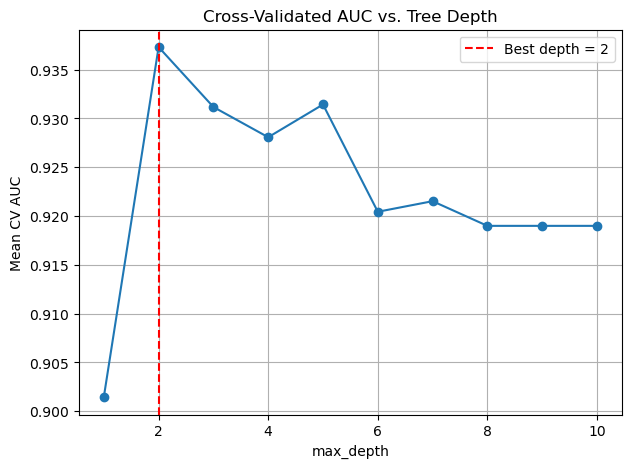

In [5]:
depths = param_grid['max_depth']
mean_auc = grid_search.cv_results_['mean_test_score']

plt.figure(figsize=(7, 5))
plt.plot(list(depths), mean_auc, marker='o')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Mean CV AUC')
plt.title('Cross-Validated AUC vs. Tree Depth')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
best_tree = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=0)
best_tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=2, random_state=0)

In [7]:
def report(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:", round(recall_score(y_true, y_pred), 3))
    print("F1-score:", round(f1_score(y_true, y_pred), 3))
    print("AUC:", round(roc_auc_score(y_true, y_proba), 3))
    print()


# train model on training
y_train_pred = best_tree.predict(X_train)
y_train_proba = best_tree.predict_proba(X_train)[:, 1]
report("TRAINING set", y_train, y_train_pred, y_train_proba)

# validation
y_val_pred = best_tree.predict(X_val)
y_val_proba = best_tree.predict_proba(X_val)[:, 1]
report("VALIDATION set", y_val, y_val_pred, y_val_proba)

# test
y_test_pred = best_tree.predict(X_test)
y_test_proba = best_tree.predict_proba(X_test)[:, 1]
report("TEST set", y_test, y_test_pred, y_test_proba)

--- TRAINING set ---
Accuracy: 0.952
Precision: 0.911
Recall: 0.965
F1-score: 0.937
AUC: 0.969

--- VALIDATION set ---
Accuracy: 0.912
Precision: 0.833
Recall: 0.952
F1-score: 0.889
AUC: 0.916

--- TEST set ---
Accuracy: 0.93
Precision: 0.84
Recall: 1.0
F1-score: 0.913
AUC: 0.956



In [8]:
cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=0),
    X_train, y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

print("CV recall scores:", [round(s, 3) for s in cv_scores])
print ("mean CV recall:", round(cv_scores.mean(), 3))
print ("Std CV recall:", round(cv_scores.std(), 3))

CV recall scores: [0.939, 0.96, 0.926, 0.912, 0.949]
mean CV recall: 0.937
Std CV recall: 0.017


In [9]:
print("Summary: train AUC = {:.3f} | mean CV AUC = {:.3f} | validation AUC = {:.3f} | test AUC = {:.3f}".format(
    roc_auc_score(y_train, y_train_proba),
    cv_scores.mean(),
    roc_auc_score(y_val, y_val_proba),
    roc_auc_score(y_test, y_test_proba)))

Summary: train AUC = 0.969 | mean CV AUC = 0.937 | validation AUC = 0.916 | test AUC = 0.956


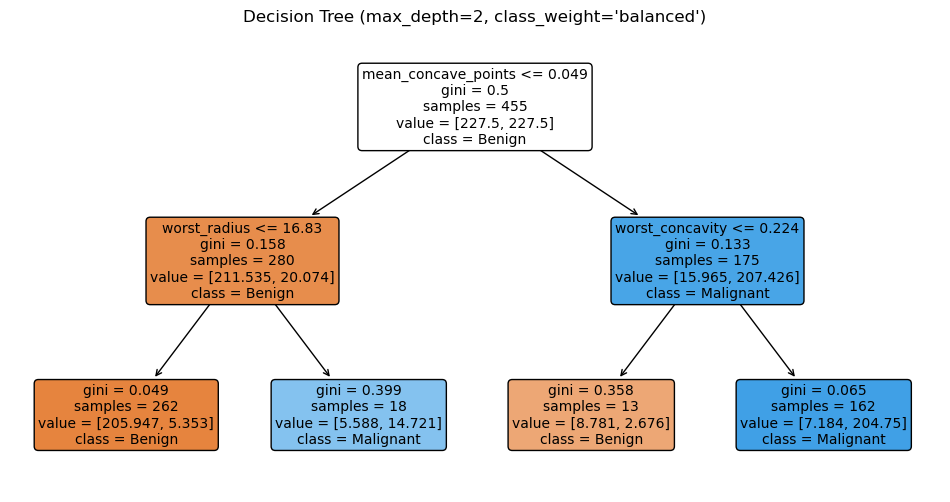

In [10]:
plt.figure(figsize=(12, 6))
plot_tree(best_tree, feature_names=X_train.columns, class_names=['Benign', 'Malignant'],
          filled=True, rounded=True, fontsize=10)
plt.title(f"Decision Tree (max_depth={best_depth}, class_weight='balanced')")
plt.show()

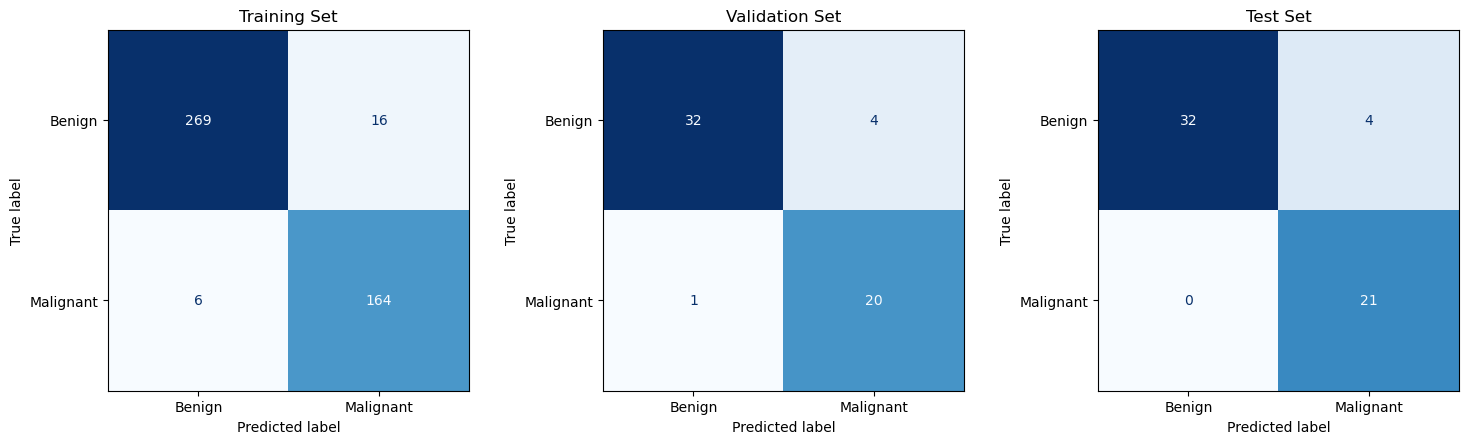

In [11]:
#confussion matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, name, y_true, y_pred in [
    (axes[0], "Training", y_train, y_train_pred),
    (axes[1], "Validation", y_val, y_val_pred),
    (axes[2], "Test", y_test, y_test_pred),
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f"{name} Set")

plt.tight_layout()
plt.show()

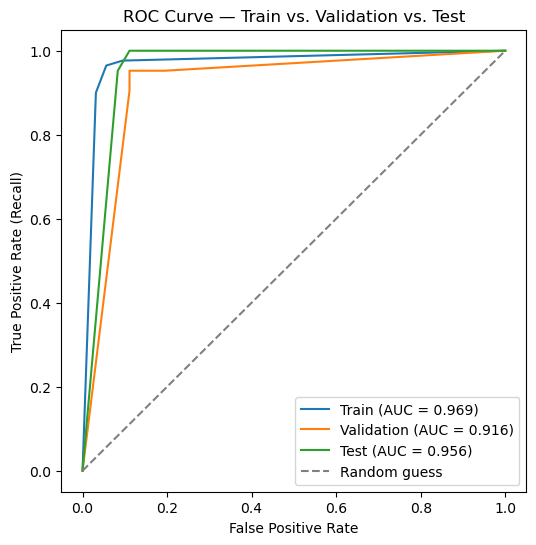

In [12]:
# ROC curve 
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

auc_train = round(roc_auc_score(y_train, y_train_proba), 3)
auc_val = round(roc_auc_score(y_val, y_val_proba), 3)
auc_test = round(roc_auc_score(y_test, y_test_proba), 3)

plt.figure(figsize=(6, 6))
plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {auc_train})')
plt.plot(fpr_val, tpr_val, label=f'Validation (AUC = {auc_val})')
plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {auc_test})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Train vs. Validation vs. Test')
plt.legend()
plt.show()